In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../historico/historical_assets.csv")

dfs_por_ticker = {tick: df_tick for tick, df_tick in df.groupby("ticker")}


type          price                                       volume           \
asset      Activo A Activo B Activo C Activo D Activo E Activo A Activo B   
2024-01-01      100      200       50      150       75     1000     5000   
2024-01-02      102      198       52      152       77     1200     5200   
2024-01-03      101      202       51      149       76     1100     5100   
2024-01-04      103      205       53      154       78     1150     5300   
2024-01-05      104      207       54      156       80     1180     5400   

type                                   
asset      Activo C Activo D Activo E  
2024-01-01     3000     2000     1500  
2024-01-02     3100     2200     1600  
2024-01-03     3050     2100     1550  
2024-01-04     3200     2300     1650  
2024-01-05     3300     2400     1700  


In [3]:
import numpy as np
import pandas as pd

prices_df = df['price']
volumes_df = df['volume']

# Retornos logarítmicos (mejor que simples)
log_returns = np.log(prices_df / prices_df.shift(1)).dropna()


In [4]:
# Retorno esperado = 0 (mañana igual que hoy)
rw_expected_returns = pd.Series(
    np.zeros(prices_df.shape[1]),
    index=prices_df.columns,
    name='RW_Return'
)


In [5]:
from statsmodels.tsa.arima.model import ARIMA

def arima_return_forecast(series, order=(1, 0, 1)):
    model = ARIMA(series, order=order)
    fit = model.fit()
    return fit.forecast(steps=1).iloc[0]


In [6]:
arima_expected_returns = {}

for asset in log_returns.columns:
    arima_expected_returns[asset] = arima_return_forecast(
        log_returns[asset]
    )

arima_expected_returns = pd.Series(
    arima_expected_returns,
    name='ARIMA_Return'
)

print("📈 Retornos esperados ARIMA:")
print(arima_expected_returns)


c:\Users\jorge\miniconda3\envs\proyecto_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\jorge\miniconda3\envs\proyecto_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\jorge\miniconda3\envs\proyecto_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\jorge\miniconda3\envs\proyecto_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


📈 Retornos esperados ARIMA:
Activo A    0.003786
Activo B    0.010344
Activo C    0.007567
Activo D    0.001177
Activo E    0.003110
Name: ARIMA_Return, dtype: float64


In [7]:
# Mezcla conservadora: 70% RW + 30% ARIMA
final_expected_returns = (
    0.7 * rw_expected_returns +
    0.3 * arima_expected_returns
)

print("\n🎯 Retornos esperados finales:")
print(final_expected_returns)



🎯 Retornos esperados finales:
asset
Activo A    0.001136
Activo B    0.003103
Activo C    0.002270
Activo D    0.000353
Activo E    0.000933
dtype: float64


In [8]:
# Sustituimos mean_returns por la señal esperada
mean_returns = final_expected_returns.values

In [12]:
import numpy as np
from scipy.optimize import minimize

# -------------------------------
# Extraer precios y volúmenes del DataFrame
prices = df['price'].values      # shape (T, N)
volumes = df['volume'].values    # shape (T, N)
tickers = df['price'].columns.tolist()

# -------------------------------
# Returns y estadísticas
returns = (prices[1:] - prices[:-1]) / prices[:-1]
mean_returns = returns.mean(axis=0)
cov_matrix = np.cov(returns.T)
avg_volume = volumes.mean(axis=0)

num_assets = prices.shape[1]

# -------------------------------
# Funciones de cartera
def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_return(weights, mean_returns):
    return weights @ mean_returns

# -------------------------------
# Función de riesgo compuesta
def complex_risk(
    weights,
    cov_matrix,
    returns,
    volumes,
    alpha=0.6,
    beta=0.3,
    gamma=0.1
):
    # 1️⃣ Riesgo Markowitz
    vol = portfolio_volatility(weights, cov_matrix)

    # 2️⃣ Penalización por bajo volumen (liquidez)
    vol_penalty = np.sum(weights / (volumes.mean(axis=0) + 1e-6))

    # 3️⃣ VaR histórico diario (percentil 5%)
    portfolio_returns = returns @ weights
    VaR = -np.percentile(portfolio_returns, 5)

    return alpha * vol + beta * vol_penalty + gamma * VaR

# Maximizar retorno → minimizar negativo
def negative_portfolio_return(weights, mean_returns):
    return -portfolio_return(weights, mean_returns)

# -------------------------------
# Restricciones y límites
target_risk = 0.05

constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {
        'type': 'ineq',
        'fun': lambda w: target_risk - complex_risk(
            w, cov_matrix, returns, volumes
        )
    }
]

bounds = tuple((0, 0.9) for _ in range(num_assets))
init_guess = np.ones(num_assets) / num_assets

# -------------------------------
# Optimización
result = minimize(
    negative_portfolio_return,
    init_guess,
    args=(mean_returns,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

# -------------------------------
# Regla de limpieza: mínimo 3% o 0
threshold = 0.03
final_weights = np.where(optimal_weights >= threshold, optimal_weights, 0)

if final_weights.sum() > 0:
    final_weights /= final_weights.sum()

# -------------------------------
# Resultados
print("Cartera óptima según riesgo compuesto:\n")

for ticker, weight in zip(tickers, final_weights):
    print(f"{ticker}: {weight:.2%}")

final_risk = complex_risk(final_weights, cov_matrix, returns, volumes)
final_return = portfolio_return(final_weights, mean_returns)

print(f"\nRiesgo compuesto de la cartera: {final_risk:.4f}")
print(f"Rentabilidad esperada diaria: {final_return:.4%}")


Cartera óptima según riesgo compuesto:

Activo A: 0.00%
Activo B: 0.00%
Activo C: 90.00%
Activo D: 0.00%
Activo E: 10.00%

Riesgo compuesto de la cartera: 0.0175
Rentabilidad esperada diaria: 1.9383%


In [13]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def predict_next_price_arima(price_series, order=(1, 1, 1)):
    """
    price_series: pd.Series con precios históricos
    order: (p, d, q)
    """
    model = ARIMA(price_series, order=order)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=1)
    return forecast.iloc[0]

predicted_prices = {}

prices_df = df['price']

for asset in prices_df.columns:
    series = prices_df[asset]
    predicted_prices[asset] = predict_next_price_arima(series)

predicted_prices = pd.Series(predicted_prices, name='Predicted Price')

print("📈 Predicción ARIMA para el próximo día:\n")
print(predicted_prices)


📈 Predicción ARIMA para el próximo día:

Activo A    103.997044
Activo B    207.539335
Activo C     53.997095
Activo D    155.456527
Activo E     80.000117
Name: Predicted Price, dtype: float64


c:\Users\jorge\miniconda3\envs\proyecto_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [17]:
next_date = df.index[-1] + pd.Timedelta(days=1)

pred_df = pd.DataFrame(
    [predicted_prices.values],
    index=[next_date],
    columns=predicted_prices.index
)

df_predicted = pd.concat([df['price'], pred_df])

print(df_predicted)

              Activo A    Activo B   Activo C    Activo D   Activo E
2024-01-01  100.000000  200.000000  50.000000  150.000000  75.000000
2024-01-02  102.000000  198.000000  52.000000  152.000000  77.000000
2024-01-03  101.000000  202.000000  51.000000  149.000000  76.000000
2024-01-04  103.000000  205.000000  53.000000  154.000000  78.000000
2024-01-05  104.000000  207.000000  54.000000  156.000000  80.000000
2024-01-06  103.997044  207.539335  53.997095  155.456527  80.000117


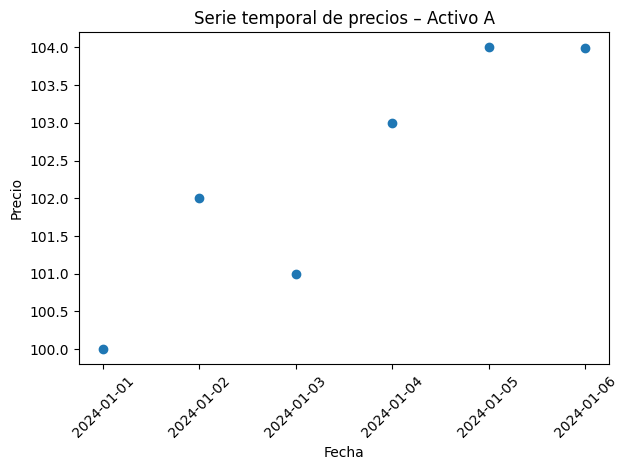

In [20]:
import matplotlib.pyplot as plt

# Seleccionar activo
asset = 'Activo A'

# Extraer serie temporal
series = df_predicted[asset]

# Crear figura
plt.figure()
plt.scatter(series.index, series.values)
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title(f'Serie temporal de precios – {asset}')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
